In [ ]:
import math

import matplotlib.pyplot as plt
import pandas as pd
from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer, GaussianCopulaSynthesizer
from sklearn.preprocessing import LabelEncoder

In [ ]:
data = pd.read_csv("..\\data\\titanic\\train.csv").drop(
    columns=["Ticket", "Cabin", "Name"]
)

data.head()

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,1,0,3,male,22.0,1,0,7.2500,S
1,2,1,1,female,38.0,1,0,71.2833,C
2,3,1,3,female,26.0,0,0,7.9250,S
3,4,1,1,female,35.0,1,0,53.1000,S
4,5,0,3,male,35.0,0,0,8.0500,S


In [169]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Sex          891 non-null    object 
 4   Age          714 non-null    float64
 5   SibSp        891 non-null    int64  
 6   Parch        891 non-null    int64  
 7   Fare         891 non-null    float64
 8   Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(2)
memory usage: 62.8+ KB


In [170]:
encoder = LabelEncoder()

In [171]:
data["Sex"] = data["Sex"].apply(lambda x: 1 if x == "male" else 0)
data["Embarked"] = encoder.fit_transform(data["Embarked"])

In [172]:
data["Embarked"].value_counts()

Embarked
2    644
0    168
1     77
3      2
Name: count, dtype: int64

In [174]:
def plot_histograms_grid(
    df: pd.DataFrame, columns: list = None, figsize=(12, 8), bins=30
):
    """
    Строит гистограммы для указанных колонок DataFrame в виде сетки.

    Параметры:
    ----------
    df : pd.DataFrame
        Исходный DataFrame.
    columns : list, optional
        Список названий колонок, для которых нужно построить гистограммы.
        Если None — используются все числовые колонки.
    figsize : tuple, optional
        Размер фигуры (ширина, высота).
    bins : int, optional
        Количество бинов в гистограмме.
    """
    if columns is None:
        # Берём только числовые колонки, если не указано иное
        columns = df.select_dtypes(include="number").columns.tolist()
    else:
        # Проверяем, что указанные колонки существуют в DataFrame
        missing = set(columns) - set(df.columns)
        if missing:
            raise ValueError(f"Следующие колонки отсутствуют в DataFrame: {missing}")

    n = len(columns)
    if n == 0:
        print("Нет колонок для построения гистограмм.")
        return

    # Определяем размер сетки
    cols = min(3, n)  # максимум 3 графика в строке
    rows = math.ceil(n / cols)

    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if n > 1 else [axes]

    for i, col in enumerate(columns):
        df[col].hist(ax=axes[i], bins=bins, edgecolor="black")
        axes[i].set_title(f"Гистограмма: {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Частота")

    # Скрываем лишние оси, если колонок меньше, чем ячеек сетки
    for j in range(n, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

## Распределения изначальной выборки

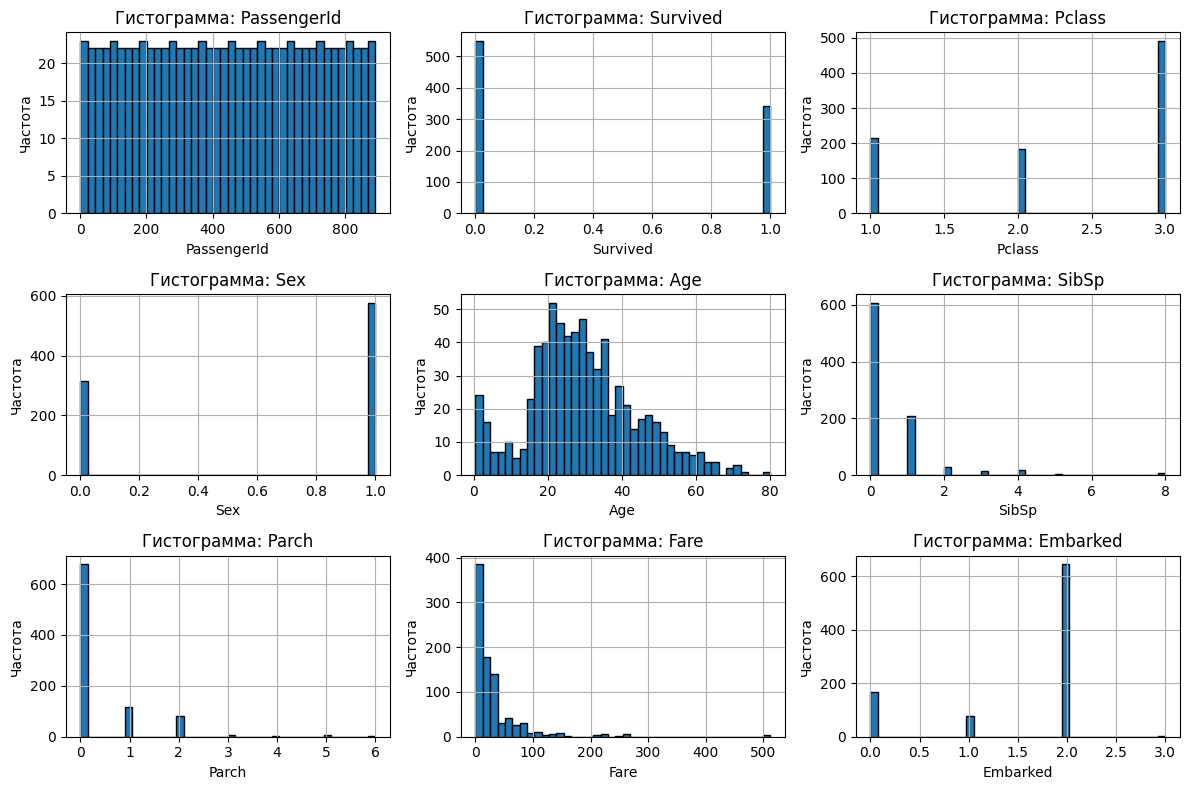

In [ ]:
fig = plot_histograms_grid(df=data, columns=data.columns, bins=40)

## Пробуем использовать **Gaussian Copula**

### Задаём метаданные

In [ ]:
metadata = Metadata()
metadata = metadata.detect_from_dataframe(data)
# metadata.set_primary_key('PassengerId')
metadata.update_column(column_name="Embarked", sdtype="categorical")
metadata.update_column(column_name="Sex", sdtype="categorical")
metadata.update_column(column_name="Pclass", sdtype="categorical")
metadata.update_column(column_name="Parch", sdtype="categorical")

metadata

{
    "tables": {
        "table": {
            "primary_key": "PassengerId",
            "columns": {
                "PassengerId": {
                    "sdtype": "id"
                },
                "Survived": {
                    "sdtype": "categorical"
                },
                "Pclass": {
                    "sdtype": "categorical"
                },
                "Sex": {
                    "sdtype": "categorical"
                },
                "Age": {
                    "sdtype": "numerical"
                },
                "SibSp": {
                    "sdtype": "categorical"
                },
                "Parch": {
                    "sdtype": "categorical"
                },
                "Fare": {
                    "sdtype": "numerical"
                },
                "Embarked": {
                    "sdtype": "categorical"
                }
            }
        }
    },
    "relationships": [],
    "METADATA_SPEC_VERSION": "V1"
}

In [ ]:
# Создаем и обучаем модель
model = GaussianCopulaSynthesizer(
    metadata=metadata,
    enforce_min_max_values=True,  # соответствуют ли синтетические данные тем же минимальным и максимальным значениям, что и реальные данные
    # numerical_distributions={'Age': 'norm'} # Распределение дискретных колонок
)
model.fit(data)

### Генерируем данные

In [195]:
synthetic_data = model.sample(num_rows=data.shape[0])
synthetic_data

,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,4326007,1,1,0,28.18,0,1,35.3794,2
1,4069891,0,3,1,32.80,2,0,39.1404,0
2,2697777,1,1,1,30.36,1,0,35.6443,2
3,10119885,1,1,0,21.09,1,0,102.8846,1
4,4368626,0,2,1,NaN,0,0,67.1371,2
...,...,...,...,...,...,...,...,...,...
886,9806827,0,3,1,42.38,1,0,29.5297,2
887,14061378,1,1,1,48.18,1,0,75.6718,2
888,10839557,0,1,1,34.79,0,0,16.0636,2
889,6302079,0,1,1,33.17,1,0,14.6992,2


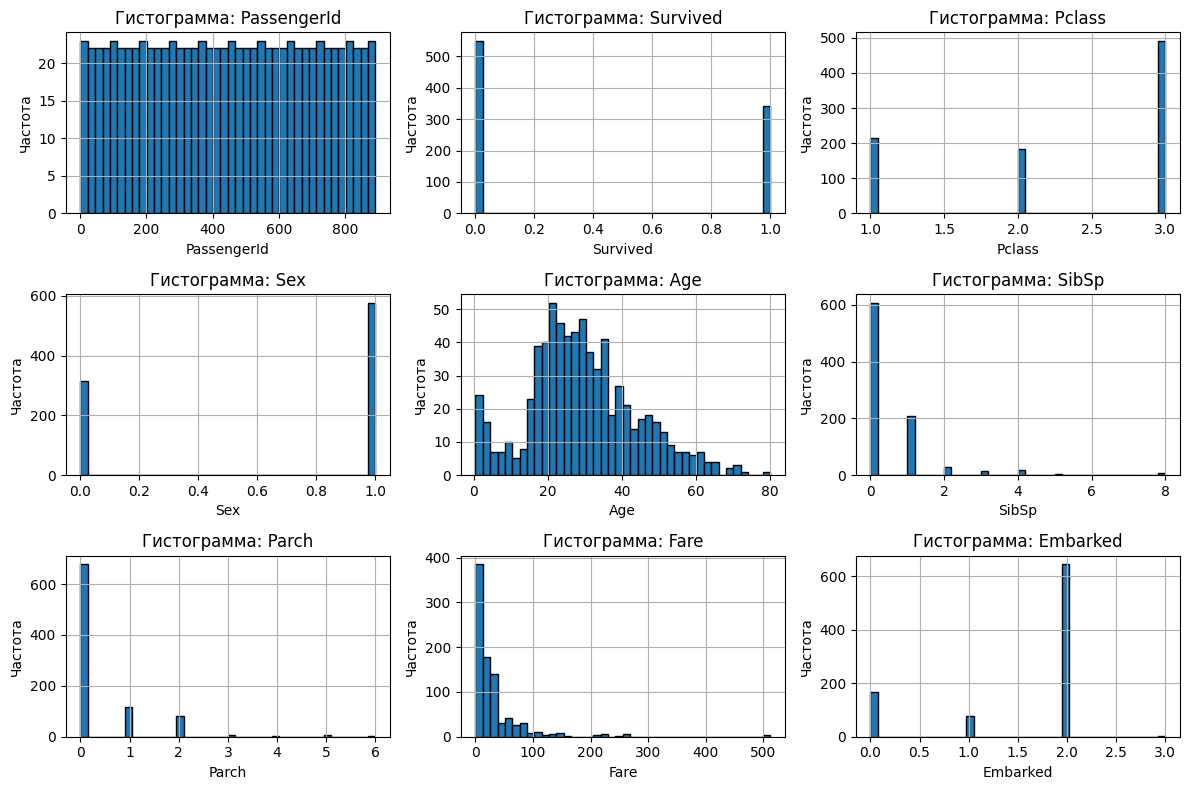

In [ ]:
plot_histograms_grid(df=data, columns=data.columns, bins=40)

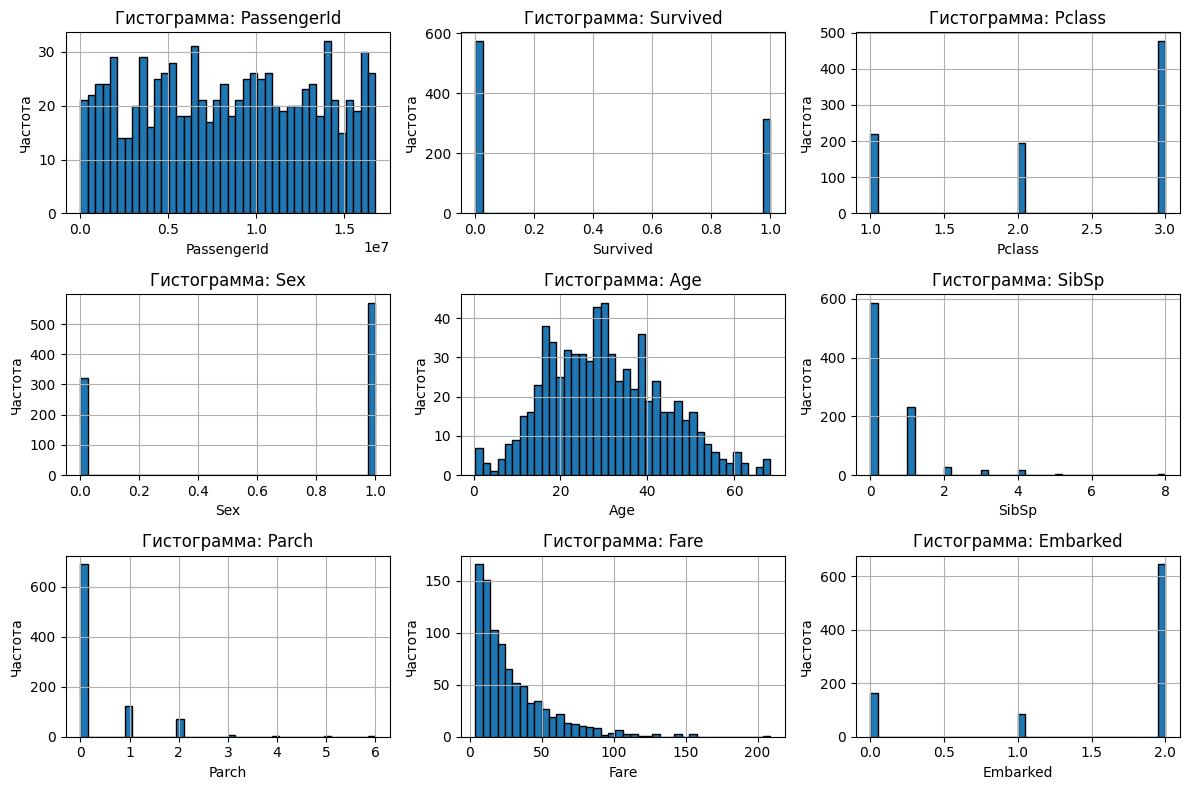

In [ ]:
plot_histograms_grid(df=synthetic_data, columns=synthetic_data.columns, bins=40)

|Изначальные данные| Синтетические|
|:-:|:-:|
|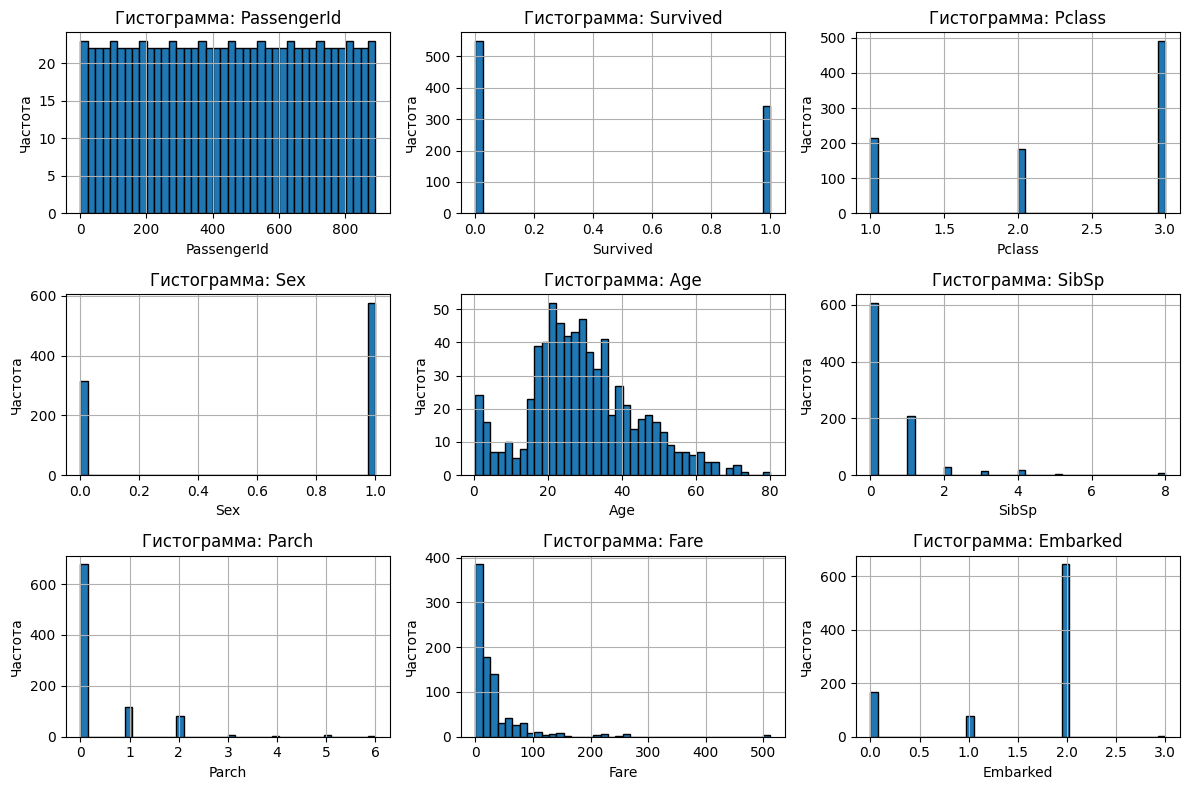|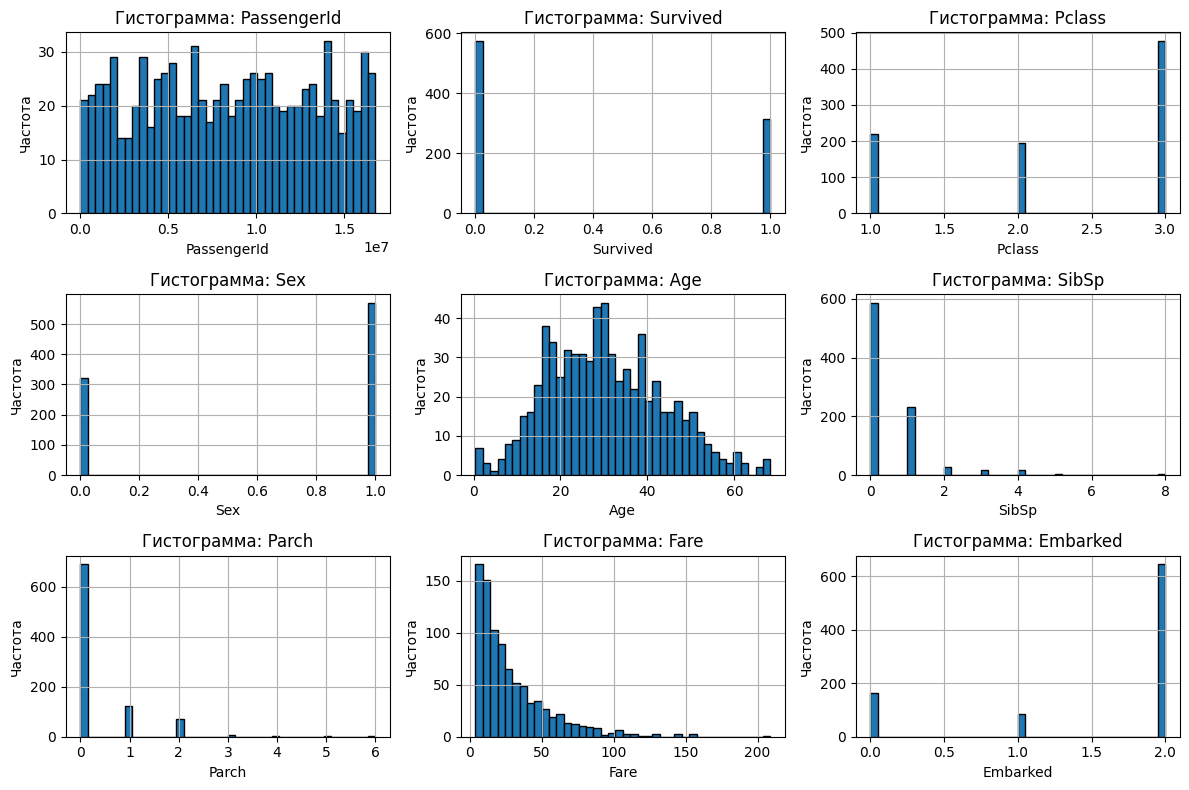|

## Пробуем использовать **CTGAN (Conditional Tabular GAN)**

In [ ]:
synthesizer = CTGANSynthesizer(metadata, enforce_min_max_values=True, batch_size=30)
synthesizer.fit(data)

synthetic_data_gan = synthesizer.sample(num_rows=data.shape[0])

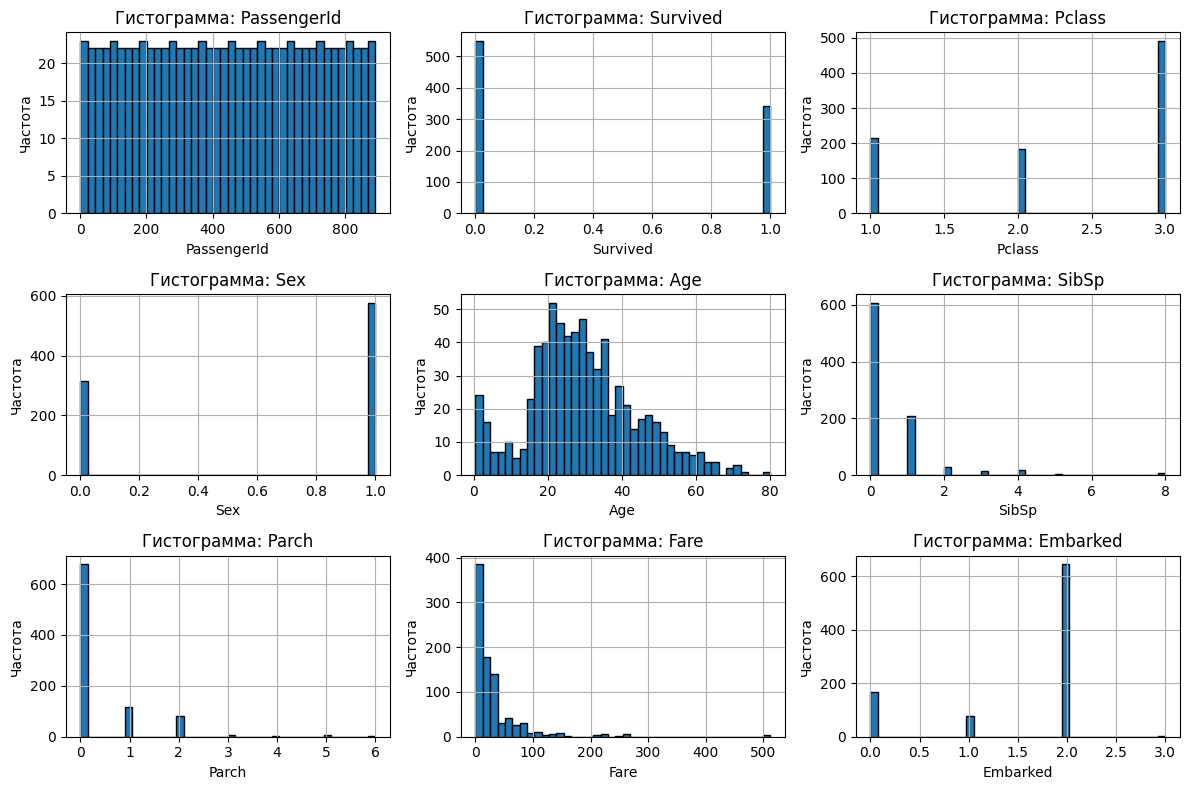

In [ ]:
plot_histograms_grid(df=data, columns=data.columns, bins=40)

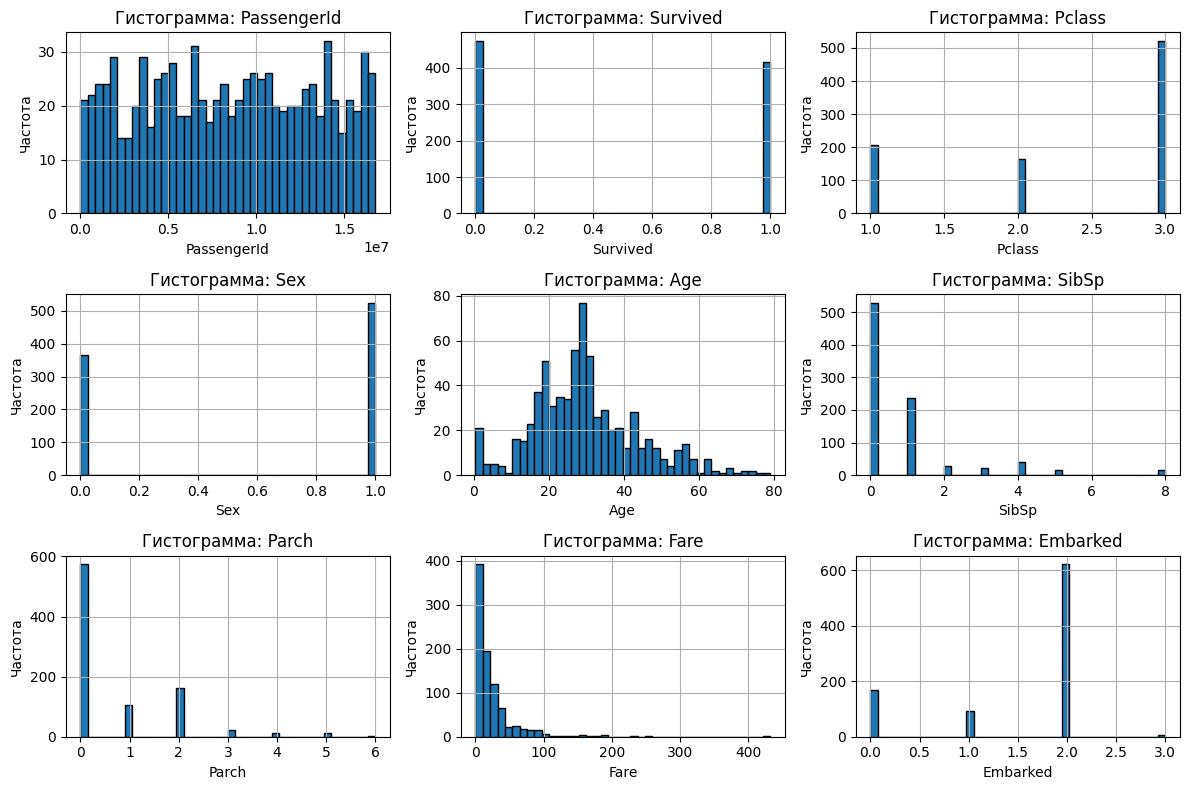

In [ ]:
plot_histograms_grid(df=synthetic_data_gan, columns=synthetic_data_gan.columns, bins=40)

|Изначальные данные| Синтетические|
|:-:|:-:|
|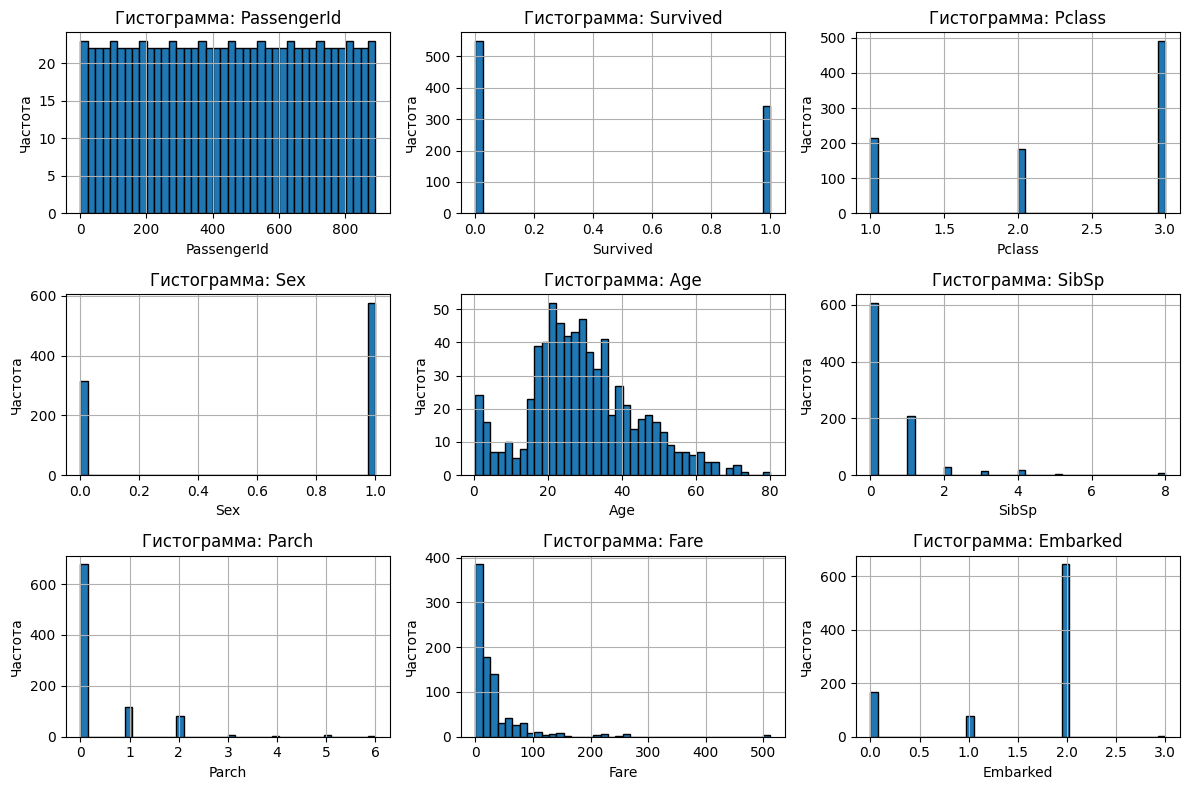|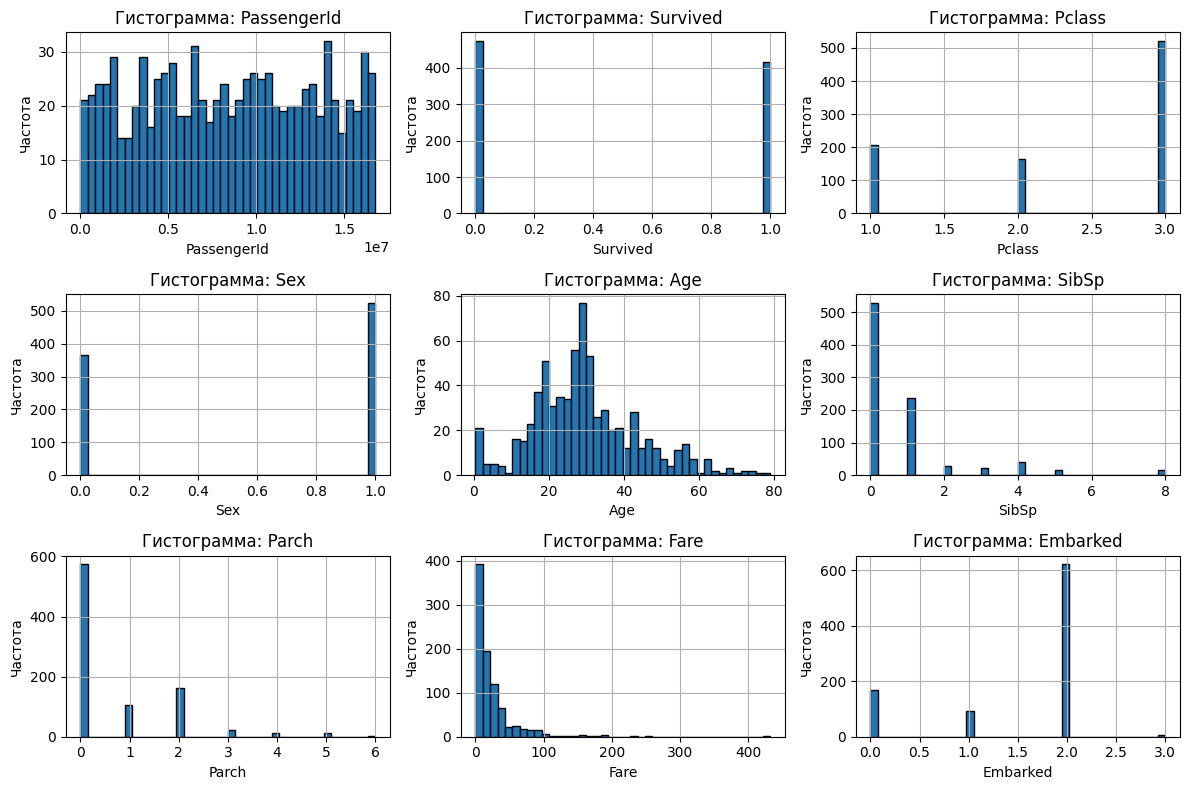|

## Сделаем общее сравнение

|Изначальные данные| Синтетические **Gaussian Copula** | Синтетические **CTGANSynthesizer** |
|:-:|:-:|:-:|
|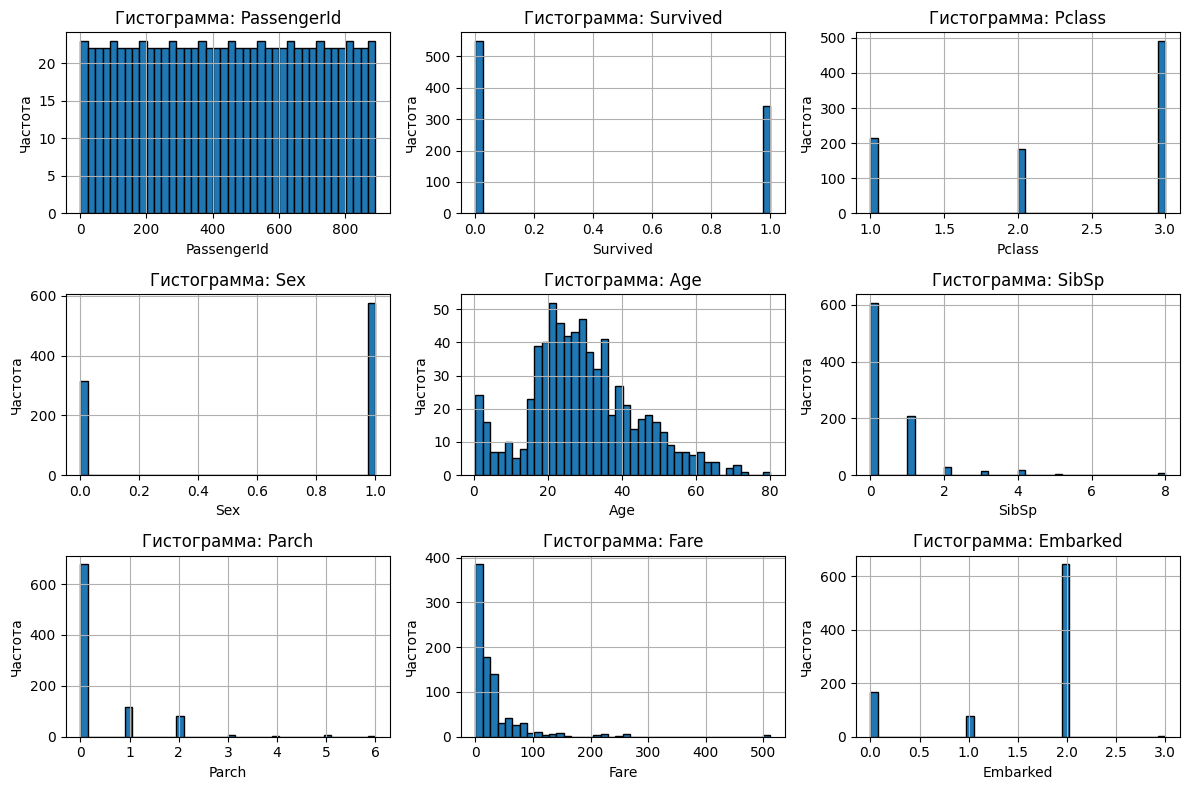| 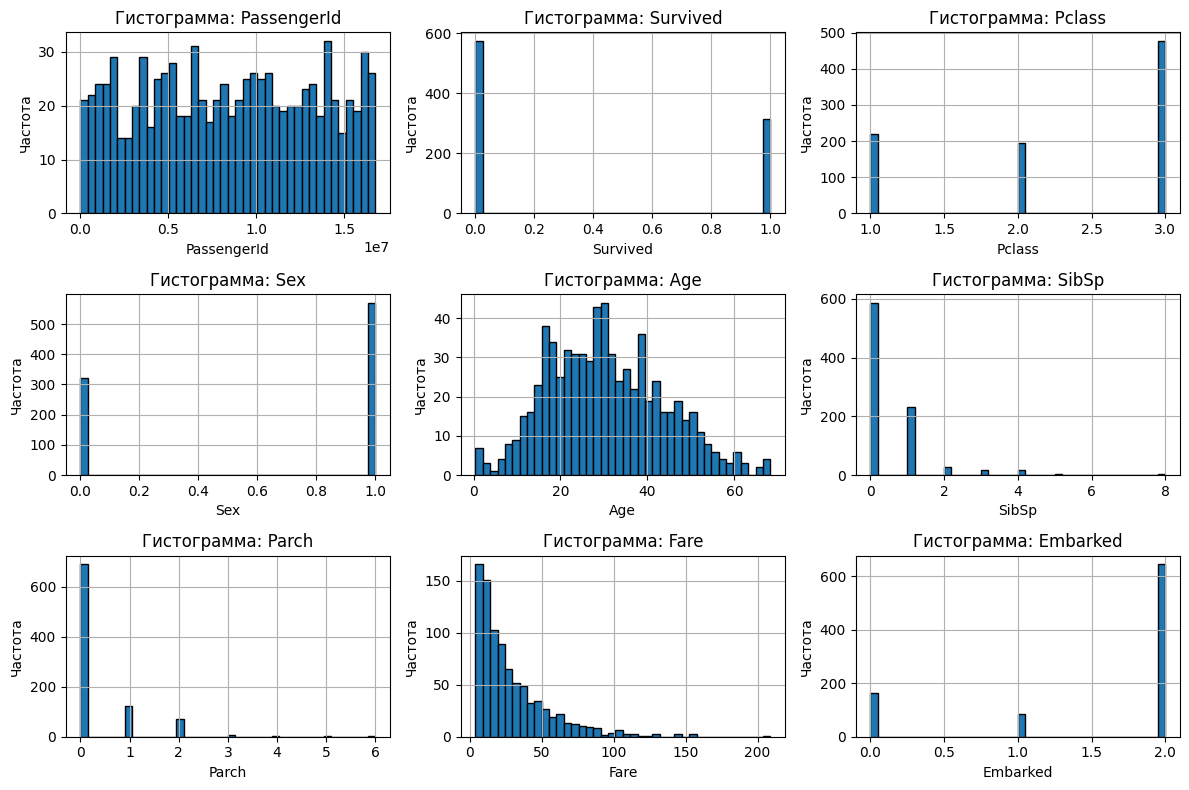 | 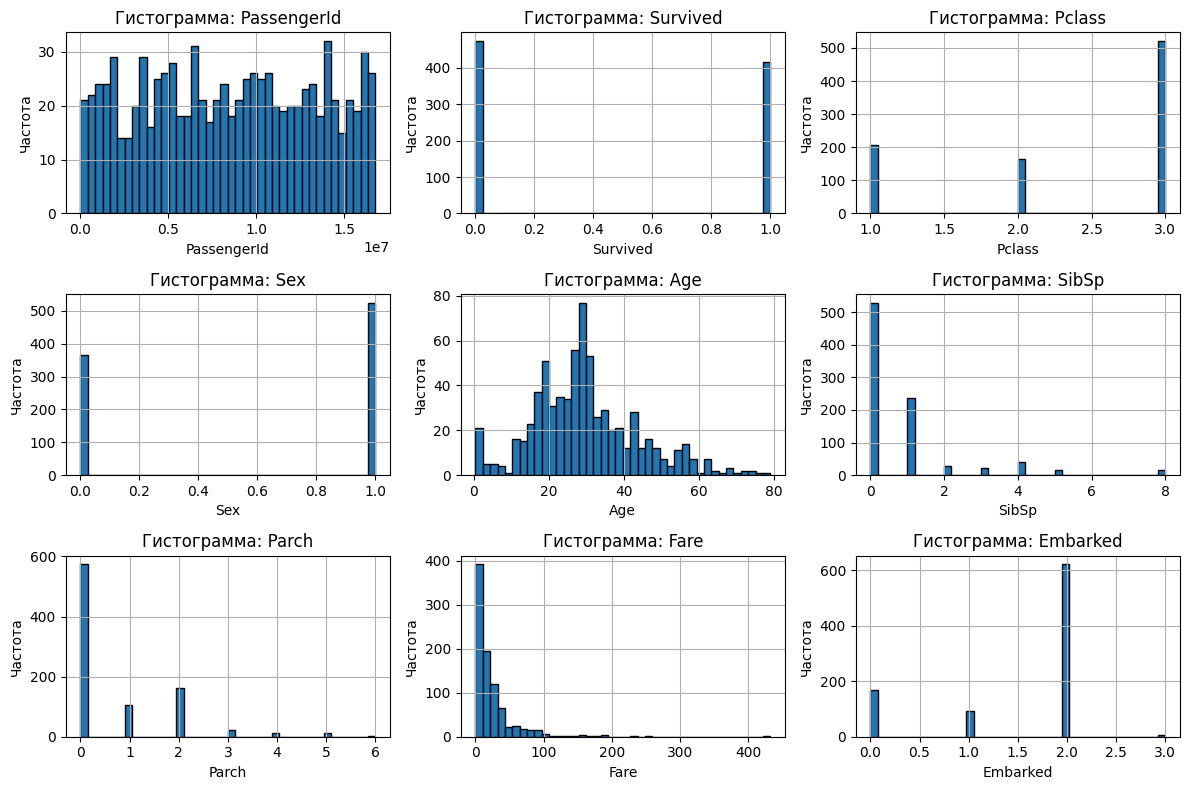|